# 8.1 序列模型

## 统计工具

时间t观察到$x_t$得到T个不独立的随机变量$(x_1, x_2, \dots, x_T) \sim p(X)$

使用条件概率去做展开：
$$
p(x) = p(x_1)p(x_2|x_1)p(x_3|x_1, x_2) \dots p(x_T|x_{1}, \dots, x_{T-1})
$$

### 对条件概率建模

$$
p(x_t|x_1, \dots, x_{t-1}) = p(x_t|f(x_1, \dots, x_{t-1}))
$$

这里是用对之前见过的数据建模（f），来预测当前时间步的输出（x_t），称之为*自回归模型*

这里也可以反着写：
$$
p(x) = p(x_T)p(x_{T-1}|x_T) \dots p(x_1|x_{2}, \dots, x_{T})
$$

知道未来的事情去推前面的事情

## 马尔科夫假设

假设当前数据只和过去$\tau$个时间步相关，而和更早的时间步无关。

$$p(x_t|x_1, \dots, x_{t-1}) = p(x_t|x_{t-\tau}, \dots, x_{t-1}) = p(x_t|f(x_{t-\tau}, \dots, x_{t-1}))$$


不用再去处理变长的数据了，直接处理定长的数据即可，这里的f可以直接去训练一个MLP模型工作

## 潜变量模型

隐变量的一个推广的类型：引入一个潜变量$h_t$去表示过去的信息：$h_t = f(x_1, \dots, x_{t-1})$

这样$x_t = p(x_t|h_t)$ 

这里的直观理解是：

$$
h_t \sim h_{t-1}, x_{t-1} \\
x_t \sim h_t, x_{t-1}
$$

## 代码模型
怎么用马尔科夫假设去训练一个MLP模型预测下一个时刻的值

生成1000个正弦函数的点，同时对正弦函数做加噪处理

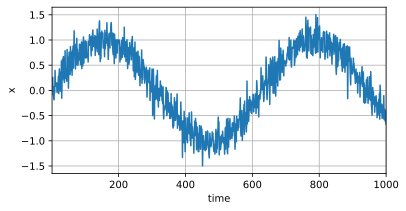

In [1]:
%matplotlib inline
import torch
from torch import nn
from d2l import torch as d2l

T = 1000  # 总共产生1000个点
time = torch.arange(1, T + 1, dtype=torch.float32)
x = torch.sin(0.01 * time) + torch.normal(0, 0.2, (T,))
d2l.plot(time, [x], 'time', 'x', xlim=[1, 1000], figsize=(6, 3))

把数据映射为数据对$y_t = x_t, x_t = [x_{t-\tau}, \dots, x_{t-1}]$

In [2]:
tau = 4
features = torch.zeros((T - tau, tau))  # 负责生成对应的矩阵
for i in range(tau):
    features[:, i] = x[i: T - tau + i]  # 按列进行填充
labels = x[tau:].reshape((-1, 1))  # label从第tau个点开始，一直到最后

batch_size, n_train = 16, 600
# 只有前n_train个样本用于训练
train_iter = d2l.load_array((features[:n_train], labels[:n_train]),
                            batch_size, is_train=True)  # 怎么用对一个数组load成一个可以迭代的iterate

训练

In [3]:
# 初始化网络权重的函数
def init_weights(m):
    if type(m) == nn.Linear:
        nn.init.xavier_uniform_(m.weight)  # 初始化权重为Xavier分布

# 一个简单的多层感知机
def get_net():
    net = nn.Sequential(nn.Linear(4, 10),
                        nn.ReLU(),
                        nn.Linear(10, 1))  # 回归最后要得到一个标量
    net.apply(init_weights)
    return net

# 平方损失。注意：MSELoss计算平方误差时不带系数1/2
loss = nn.MSELoss(reduction='none')  # 回归问题用MSE损失函数

def train(net, train_iter, loss, epochs, lr):
    trainer = torch.optim.Adam(net.parameters(), lr)
    for epoch in range(epochs):
        for X, y in train_iter:
            trainer.zero_grad()
            l = loss(net(X), y)
            l.sum().backward() # 先求和再做backward()
# 因为pytorch里面，backward（）必须要从一个标量出发，loss中reduction参数指定为none
            trainer.step() # 执行梯度更新操作：param -= -lr * adam_update(param.grad)
        print(f'epoch {epoch + 1}, '
              f'loss: {d2l.evaluate_loss(net, train_iter, loss):f}')

net = get_net()
train(net, train_iter, loss, 5, 0.01)

epoch 1, loss: 0.058011
epoch 2, loss: 0.051841
epoch 3, loss: 0.050276
epoch 4, loss: 0.050403
epoch 5, loss: 0.050283


这里说明一个小问题，求和不会影响反向传播的结果：
1. 为什么要用l.sum().backward()?
PyTorch 的 Autograd（自动求导）引擎在设计时，默认的目标函数必须是一个标量。
2. sum不会影响grad操作：
假设批量中有两个样本，它们的损失分别是 $l_1$ 和 $l_2$。我们对总损失 $L = l_1 + l_2$ 关于某个权重参数 $w$ 求偏导：$$\frac{\partial L}{\partial w} = \frac{\partial (l_1 + l_2)}{\partial w} = \frac{\partial l_1}{\partial w} + \frac{\partial l_2}{\partial w}$$
* .sum().backward()算出的是整个 Batch 梯度的总和；
* .mean().backward()，你算出的是整个 Batch 梯度的平均值


## 预测下一个时间步

### 单步预测

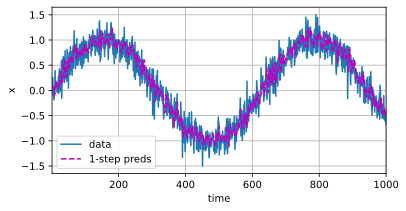

In [4]:
onestep_preds = net(features)
d2l.plot([time, time[tau:]],
         [x.detach().numpy(), onestep_preds.detach().numpy()], 'time',
         'x', legend=['data', '1-step preds'], xlim=[1, 1000],
         figsize=(6, 3))  # 用之前训练的数据网络去模拟预测下一个时间步

### 多步预测

k步预测：基于观察到的$x_t$序列，预测$\hat x_{t+k}$
也就是说，在未来的预测中，我们必须使用自己的预测来作为输入，而不是真实数据，因为在真实的“预测未来”场景中，未来的真实数据根本还不存在。
下面的代码先看一下效果怎么样，还是使用单步预测，但是只有前604个数据使用真实数据，后396个数据使用预测值。

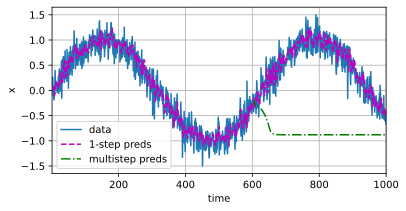

In [ ]:
multistep_preds = torch.zeros(T)
multistep_preds[: n_train + tau] = x[: n_train + tau]
for i in range(n_train + tau, T):
    multistep_preds[i] = net(
        multistep_preds[i - tau:i].reshape((1, -1)))    # 到后面的预测步，使用预测值作为输入

d2l.plot([time, time[tau:], time[n_train + tau:]],
         [x.detach().numpy(), onestep_preds.detach().numpy(),
          multistep_preds[n_train + tau:].detach().numpy()], 'time',
         'x', legend=['data', '1-step preds', 'multistep preds'],
         xlim=[1, 1000], figsize=(6, 3))

预测的效果很差，经过几个预测步之后，会衰落到常数水平：
* 存在累计误差；
* 衰减到常数：主要是：
1. 误差的指数级放大：假设模型在预测第一步时，产生了一个微小的误差 $\epsilon$。在预测第二步时，这个带有误差的值被放进了输入特征中，导致第二步的误差更大。等到预测了 $\tau$ 步之后，模型输入给自己的 $\tau$ 个特征全部都是带有误差的假数据；
2. 分布偏移：网络是一个简单的多层感知机（MLP），它是在“真实的正弦波片段”上训练出来的。当由于误差累积，输入序列的波形变得扭曲时，模型遇到了一种它在训练时从未见过的奇怪输入分布。

看一下整个序列的预测结果

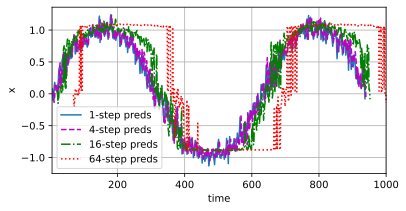

In [ ]:
max_steps = 64

features = torch.zeros((T - tau - max_steps + 1, tau + max_steps))
# 前tau列是来自x的观测，tau到tau+max_steps-1列是来自预测值
for i in range(tau): # 这里因为net的收入维度被设置为tau，所以前tau个特征是必须来自x的观测值的
# 在这里tau的含义是需要tau个时间步的输入才可以预测输出
    features[:, i] = x[i: i + T - tau - max_steps + 1]

# 列i（i>=tau）是来自（i-tau+1）步的预测，其时间步从（i）到（i+T-tau-max_steps+1）
for i in range(tau, tau + max_steps):
    features[:, i] = net(features[:, i - tau:i]).reshape(-1)  # 到后面的预测步，使用预测值作为输入

steps = (1, 4, 16, 64)
d2l.plot([time[tau + i - 1: T - max_steps + i] for i in steps],
         [features[:, (tau + i - 1)].detach().numpy() for i in steps], 'time', 'x',
         legend=[f'{i}-step preds' for i in steps], xlim=[5, 1000],
         figsize=(6, 3))